# EnergiAI – Inteligencia para el Consumo Energético

# CD3 – Modelado Predictivo para la Clasificación de la Eficiencia Energética

---

### Hackathon ONE G9 | Alura + Oracle

**Proyecto:** EnergiAI – Inteligencia para el Consumo Energético

**Módulo:** Científico de Datos 3 (CD3)

**Objetivo:**
Construir un modelo de Machine Learning capaz de clasificar el nivel de eficiencia energética de un hogar mediante un Índice de Eficiencia Energética (IEE), utilizando los conjuntos de datos procesados entregados por CD2.

---

## Introducción

En este notebook se desarrolla el proceso completo de modelado predictivo para el módulo CD3 del proyecto EnergiAI. El flujo de trabajo comprende la comprensión del conjunto de datos, la construcción del Índice de Eficiencia Energética (IEE), la generación de la variable objetivo, el entrenamiento y evaluación de diferentes algoritmos de clasificación, la validación del modelo seleccionado y el análisis de interpretabilidad. El modelo obtenido será exportado para su posterior integración con el microservicio desarrollado en FastAPI y el backend del proyecto.

---

## 1. Descripción del Dataset

Se realiza una inspección inicial del conjunto de datos para verificar su estructura, calidad y características generales antes del proceso de modelado.

### Train

In [1]:
from pathlib import Path
import pandas as pd

# Ruta base del proyecto
BASE_DIR = Path("../../")

# Cargar datasets
train = pd.read_csv(BASE_DIR / "data" / "processed" / "smart_home_train.csv")
test = pd.read_csv(BASE_DIR / "data" / "processed" / "smart_home_test.csv")

In [2]:
# Dimensiones de los conjuntos de entrenamiento y prueba
print(f"Train: {train.shape}")
print(f"Test : {test.shape}")

Train: (400, 6)
Test : (100, 6)


In [3]:
# Información general
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Home ID               400 non-null    int64  
 1   consumo_kwh           400 non-null    float64
 2   cantidad_personas     400 non-null    int64  
 3   cantidad_equipos      400 non-null    int64  
 4   temperatura_exterior  400 non-null    float64
 5   uso_horario_pico      400 non-null    bool   
dtypes: bool(1), float64(2), int64(3)
memory usage: 16.1 KB


In [4]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Home ID               100 non-null    int64  
 1   consumo_kwh           100 non-null    float64
 2   cantidad_personas     100 non-null    int64  
 3   cantidad_equipos      100 non-null    int64  
 4   temperatura_exterior  100 non-null    float64
 5   uso_horario_pico      100 non-null    bool   
dtypes: bool(1), float64(2), int64(3)
memory usage: 4.1 KB


In [5]:
# Primeros registros
train.head()

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico
0,250,315.49,5,10,14.159709,False
1,434,309.97,2,10,14.605660,False
2,20,277.74,4,10,13.748901,False
3,323,286.06,3,10,14.496842,False
4,333,291.22,3,10,14.787374,False


In [6]:
# Primeros registros
test.head()

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico
0,362,320.88,1,10,16.473913,False
1,74,339.41,4,10,14.444550,False
2,375,281.64,1,10,14.646500,False
3,156,306.27,4,10,14.492040,False
4,105,317.73,1,10,14.840102,False


In [7]:
# Estadísticas descriptivas
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Home ID,400.0,249.027500,140.580382,2.00,132.500000,246.500000,368.250000,500.000000
consumo_kwh,400.0,299.907500,27.688922,223.64,281.710000,299.565000,316.572500,391.500000
cantidad_personas,400.0,3.007500,1.472367,1.00,2.000000,3.000000,4.000000,5.000000
cantidad_equipos,400.0,10.000000,0.000000,10.00,10.000000,10.000000,10.000000,10.000000
temperatura_exterior,400.0,14.998226,0.963389,12.62,14.304737,14.986038,15.656942,17.954144


In [8]:
# Valores nulos
train.isnull().sum()

Home ID                 0
consumo_kwh             0
cantidad_personas       0
cantidad_equipos        0
temperatura_exterior    0
uso_horario_pico        0
dtype: int64

In [9]:
test.isnull().sum()

Home ID                 0
consumo_kwh             0
cantidad_personas       0
cantidad_equipos        0
temperatura_exterior    0
uso_horario_pico        0
dtype: int64

In [10]:
# Registros duplicados
print(f"Duplicados Train: {train.duplicated().sum()}")
print(f"Duplicados Test : {test.duplicated().sum()}")

Duplicados Train: 0
Duplicados Test : 0


In [11]:
pd.DataFrame({
    "Tipo de dato": train.dtypes,
    "Valores únicos": train.nunique()
})

,Tipo de dato,Valores únicos
Home ID,int64,400
consumo_kwh,float64,391
cantidad_personas,int64,5
cantidad_equipos,int64,1
temperatura_exterior,float64,400
uso_horario_pico,bool,1


### Distribución de las variables

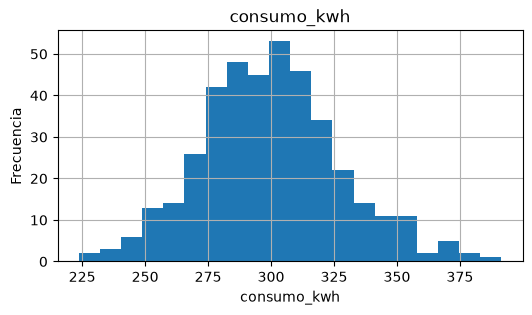

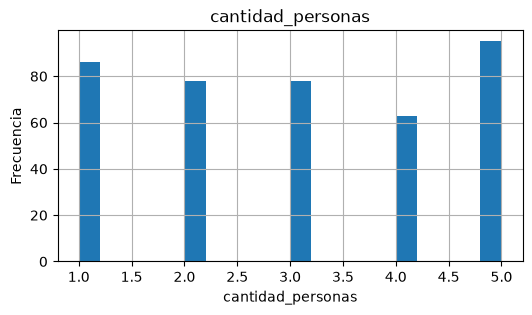

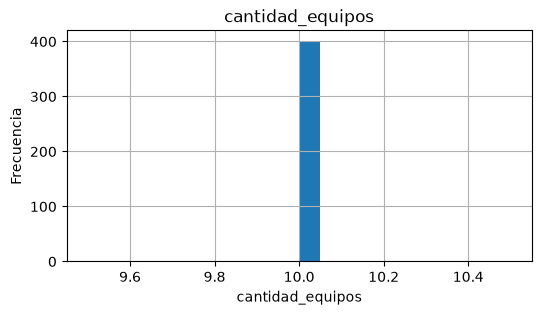

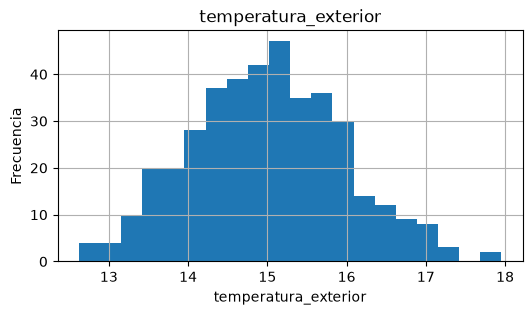

In [12]:
import matplotlib.pyplot as plt

variables = [
    "consumo_kwh",
    "cantidad_personas",
    "cantidad_equipos",
    "temperatura_exterior"
]

for variable in variables:
    plt.figure(figsize=(6,3))
    train[variable].hist(bins=20)
    plt.title(variable)
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()
    

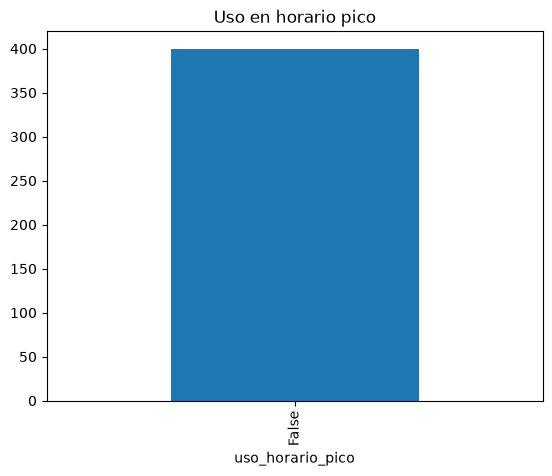

In [13]:
train["uso_horario_pico"].value_counts().plot.bar()
plt.title("Uso en horario pico")
plt.show()

In [14]:
resumen = pd.DataFrame({
    "Tipo": train.dtypes,
    "Nulos": train.isnull().sum(),
    "Únicos": train.nunique()
})

resumen

,Tipo,Nulos,Únicos
Home ID,int64,0,400
consumo_kwh,float64,0,391
cantidad_personas,int64,0,5
cantidad_equipos,int64,0,1
temperatura_exterior,float64,0,400
uso_horario_pico,bool,0,1


Se identificó que las variables cantidad_equipos y uso_horario_pico presentan un único valor en todos los registros del conjunto de entrenamiento. Aunque forman parte de la estructura de entrada del modelo, no aportan capacidad discriminativa durante el entrenamiento debido a su ausencia de variabilidad.

### Test

In [15]:
# Calidad de los datos
pd.DataFrame({
    "Tipo de dato": test.dtypes,
    "Valores únicos": test.nunique(),
    "Valores nulos": test.isnull().sum()
})

,Tipo de dato,Valores únicos,Valores nulos
Home ID,int64,100,0
consumo_kwh,float64,100,0
cantidad_personas,int64,5,0
cantidad_equipos,int64,1,0
temperatura_exterior,float64,100,0
uso_horario_pico,bool,1,0


In [16]:
# Registros duplicados
test.duplicated().sum()

np.int64(0)

In [17]:
# Estadísticas descriptivas
test.describe().T

,count,mean,std,min,25%,50%,75%,max
Home ID,100.0,256.39000,159.763518,1.000000,86.500000,280.000000,392.750000,498.000000
consumo_kwh,100.0,300.32160,25.221680,236.140000,285.067500,304.630000,316.185000,370.500000
cantidad_personas,100.0,2.92000,1.411926,1.000000,2.000000,3.000000,4.000000,5.000000
cantidad_equipos,100.0,10.00000,0.000000,10.000000,10.000000,10.000000,10.000000,10.000000
temperatura_exterior,100.0,14.72906,1.127375,11.441624,13.987856,14.663012,15.586046,17.073096


La inspección de los conjuntos de entrenamiento y prueba muestra que las variables cantidad_equipos y uso_horario_pico presentan un único valor en todos los registros. Aunque estas variables hacen parte de la estructura de entrada definida para el modelo, su ausencia de variabilidad impide que aporten capacidad discriminativa durante el entrenamiento.

## 2. Construcción del Índice de Eficiencia Energética (IEE)

Se analiza el comportamiento de las variables disponibles con el fin de diseñar un Índice de Eficiencia Energética (IEE) técnicamente sustentado, que permita clasificar el nivel de eficiencia energética de cada hogar.

## 2.1 Análisis de las variables

Se analiza el comportamiento de las variables disponibles para identificar su aporte potencial en la construcción del Índice de Eficiencia Energética (IEE).

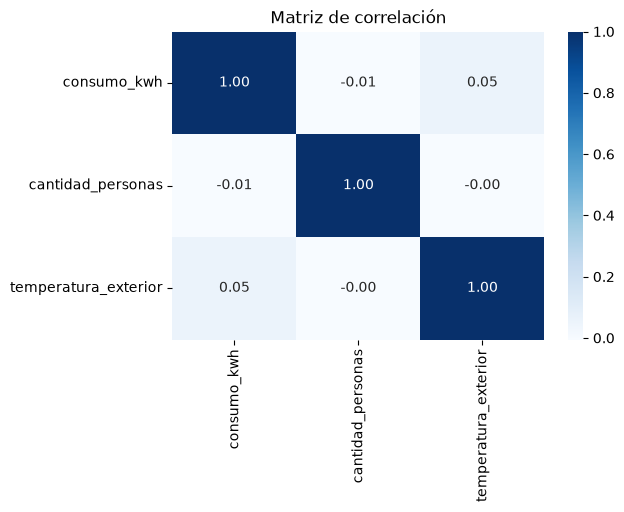

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = [
    "consumo_kwh",
    "cantidad_personas",
    "temperatura_exterior"
]

corr = train[variables].corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Matriz de correlación")
plt.show()

Cómo cambia el consumo respecto al número de personas

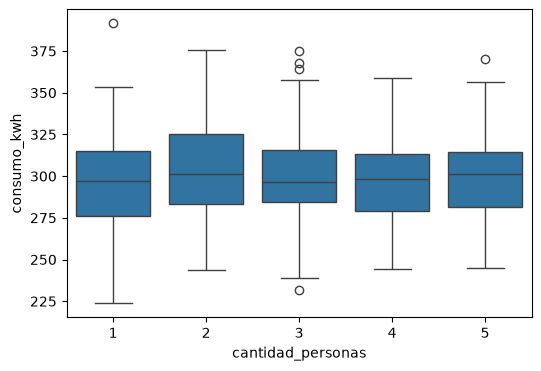

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train,
    x="cantidad_personas",
    y="consumo_kwh"
)

plt.show()

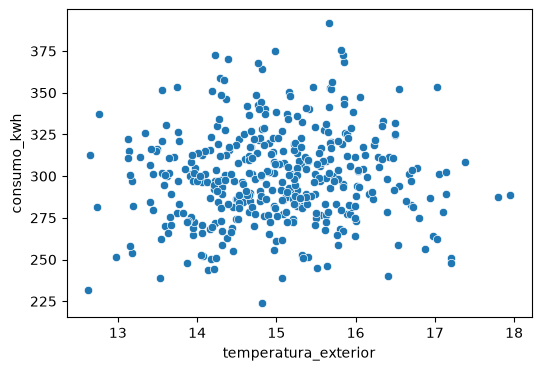

In [20]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=train,
    x="temperatura_exterior",
    y="consumo_kwh"
)

plt.show()

distribución del consumo

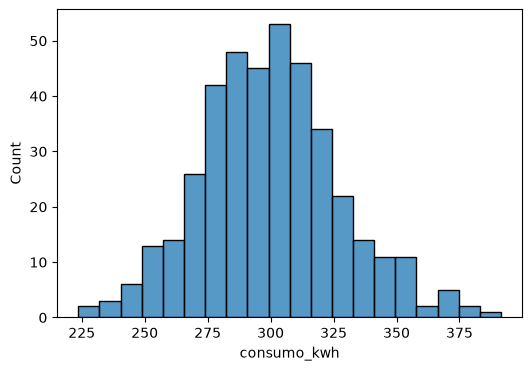

In [21]:
plt.figure(figsize=(6,4))

sns.histplot(
    train["consumo_kwh"],
    bins=20
)

plt.show()

## 2.2 Construcción de variables de apoyo para calcular el IEE

In [58]:
# Función de normalización Min-Max
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

In [59]:
# Normalización del consumo
train["consumo_norm"] = min_max_normalize(train["consumo_kwh"])

# Inversión de la escala (menor consumo = mayor eficiencia)
train["eficiencia_consumo"] = 1 - train["consumo_norm"]

In [60]:
# Consumo por habitante
train["consumo_persona"] = (
    train["consumo_kwh"] /
    train["cantidad_personas"]
)

# Normalización
train["consumo_persona_norm"] = min_max_normalize(
    train["consumo_persona"]
)

# Inversión de la escala
train["eficiencia_persona"] = (
    1 - train["consumo_persona_norm"]
)

## 2.3 Construcción del IEE

In [61]:
# Índice de Eficiencia Energética (0 - 100)
train["IEE"] = (
    train["eficiencia_consumo"] +
    train["eficiencia_persona"]
) / 2 * 100

In [66]:
train[
    [
        "consumo_kwh",
        "cantidad_personas",
        "consumo_persona",
        "IEE"
    ]
].head()

,consumo_kwh,cantidad_personas,consumo_persona,IEE
0,315.49,5,63.098000,70.583349
1,309.97,2,154.985000,58.813259
2,277.74,4,69.435000,80.902718
3,286.06,3,95.353333,74.640720
4,291.22,3,97.073333,72.852627


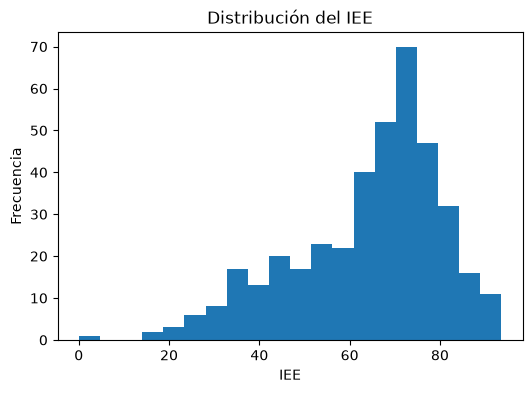

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(train["IEE"], bins=20)

plt.title("Distribución del IEE")
plt.xlabel("IEE")
plt.ylabel("Frecuencia")

plt.show()

In [67]:
# Parámetros de normalización obtenidos del conjunto de entrenamiento
consumo_min = train["consumo_kwh"].min()
consumo_max = train["consumo_kwh"].max()

consumo_persona_min = train["consumo_persona"].min()
consumo_persona_max = train["consumo_persona"].max()

In [68]:
train[
    [
        "eficiencia_consumo",
        "eficiencia_persona"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
eficiencia_consumo,400.0,0.545648,0.164952,0.0,0.446369,0.547689,0.654057,1.0
eficiencia_persona,400.0,0.736822,0.263901,0.0,0.651416,0.851664,0.943483,1.0


In [69]:
train[
    [
        "eficiencia_consumo",
        "eficiencia_persona"
    ]
].corr()

,eficiencia_consumo,eficiencia_persona
eficiencia_consumo,1.000000,0.135587
eficiencia_persona,0.135587,1.000000


In [70]:
train["IEE"].describe()

count    400.000000
mean      64.123494
std       16.481615
min        0.000000
25%       53.758594
50%       68.192525
75%       75.153260
max       93.631598
Name: IEE, dtype: float64

In [71]:
train["IEE"].quantile([0.25, 0.50, 0.75])

0.25    53.758594
0.50    68.192525
0.75    75.153260
Name: IEE, dtype: float64

In [72]:
columnas_auxiliares = [
    "consumo_norm",
    "eficiencia_consumo",
    "consumo_persona",
    "consumo_persona_norm",
    "eficiencia_persona",
    "temperatura_norm"
]

train.drop(columns=columnas_auxiliares, inplace=True, errors="ignore")

In [73]:
train.head()

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico,IEE,categoria
0,250,315.49,5,10,14.159709,False,70.583349,Moderado
1,434,309.97,2,10,14.605660,False,58.813259,Moderado
2,20,277.74,4,10,13.748901,False,80.902718,Eficiente
3,323,286.06,3,10,14.496842,False,74.640720,Moderado
4,333,291.22,3,10,14.787374,False,72.852627,Moderado


In [74]:
train.nsmallest(5, "IEE")

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico,IEE,categoria
84,455,391.50,1,10,15.659016,False,0.000000,Ineficiente
222,45,353.58,1,10,17.028111,False,16.830958,Ineficiente
363,345,353.11,1,10,15.672646,False,17.039570,Ineficiente
251,413,347.76,1,10,15.168950,False,19.414190,Ineficiente
293,217,346.35,1,10,14.361111,False,20.040025,Ineficiente


## 2.4 Clasificación del IEE

In [76]:
# Clasificación del Índice de Eficiencia Energética
def clasificar_iee(iee):

    if iee >= 80:
        return "Eficiente"

    elif iee >= 50:
        return "Moderado"

    else:
        return "Ineficiente"

In [77]:
train["categoria"] = train["IEE"].apply(clasificar_iee)

In [78]:
train["categoria"].value_counts()

categoria
Moderado       259
Ineficiente     82
Eficiente       59
Name: count, dtype: int64

In [79]:
train["categoria"].value_counts(normalize=True) * 100

categoria
Moderado       64.75
Ineficiente    20.50
Eficiente      14.75
Name: proportion, dtype: float64

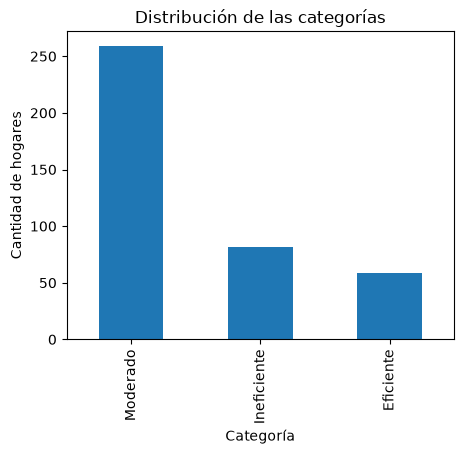

In [80]:
import matplotlib.pyplot as plt

train["categoria"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Distribución de las categorías")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de hogares")

plt.show()

In [82]:
model_data = train.copy()
model_data

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico,IEE,categoria
0,250,315.49,5,10,14.159709,False,70.583349,Moderado
1,434,309.97,2,10,14.605660,False,58.813259,Moderado
2,20,277.74,4,10,13.748901,False,80.902718,Eficiente
3,323,286.06,3,10,14.496842,False,74.640720,Moderado
4,333,291.22,3,10,14.787374,False,72.852627,Moderado
...,...,...,...,...,...,...,...,...
395,107,261.67,4,10,15.069430,False,86.275948,Eficiente
396,271,313.02,5,10,14.926570,False,71.391199,Moderado
397,349,293.22,5,10,16.038500,False,77.867080,Moderado
398,436,310.65,5,10,16.473039,False,72.166342,Moderado


## 2.5 Preparación del conjunto de datos de prueba

In [83]:
# Copia del conjunto de prueba
model_test = test.copy()
model_test

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico
0,362,320.88,1,10,16.473913,False
1,74,339.41,4,10,14.444550,False
2,375,281.64,1,10,14.646500,False
3,156,306.27,4,10,14.492040,False
4,105,317.73,1,10,14.840102,False
...,...,...,...,...,...,...
95,348,290.18,1,10,13.974396,False
96,87,292.53,2,10,13.357000,False
97,76,259.21,3,10,14.568333,False
98,439,275.29,2,10,15.059898,False


In [84]:
# Consumo por habitante
model_test["consumo_persona"] = (
    model_test["consumo_kwh"] /
    model_test["cantidad_personas"]
)

In [85]:
# Función de transformación Min-Max
def min_max_transform(series, minimo, maximo):
    return (series - minimo) / (maximo - minimo)

In [86]:
# Normalización del consumo
model_test["consumo_norm"] = min_max_transform(
    model_test["consumo_kwh"],
    consumo_min,
    consumo_max
)

# Eficiencia por consumo
model_test["eficiencia_consumo"] = (
    1 - model_test["consumo_norm"]
)

In [87]:
# Normalización del consumo por persona
model_test["consumo_persona_norm"] = min_max_transform(
    model_test["consumo_persona"],
    consumo_persona_min,
    consumo_persona_max
)

# Eficiencia por persona
model_test["eficiencia_persona"] = (
    1 - model_test["consumo_persona_norm"]
)

In [88]:
# Índice de Eficiencia Energética
model_test["IEE"] = (
    model_test["eficiencia_consumo"] +
    model_test["eficiencia_persona"]
) / 2 * 100

In [89]:
# Clasificación del IEE
model_test["categoria"] = model_test["IEE"].apply(clasificar_iee)

In [90]:
model_test.head()

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico,consumo_persona,consumo_norm,eficiencia_consumo,consumo_persona_norm,eficiencia_persona,IEE,categoria
0,362,320.88,1,10,16.473913,False,320.8800,0.579292,0.420708,0.793808,0.206192,31.344996,Ineficiente
1,74,339.41,4,10,14.444550,False,84.8525,0.689682,0.310318,0.104668,0.895332,60.282487,Moderado
2,375,281.64,1,10,14.646500,False,281.6400,0.345526,0.654474,0.679237,0.320763,48.761842,Ineficiente
3,156,306.27,4,10,14.492040,False,76.5675,0.492255,0.507745,0.080478,0.919522,71.363312,Moderado
4,105,317.73,1,10,14.840102,False,317.7300,0.560527,0.439473,0.784611,0.215389,32.743137,Ineficiente


In [91]:
model_test["categoria"].value_counts()

categoria
Moderado       68
Ineficiente    19
Eficiente      13
Name: count, dtype: int64

In [92]:
columnas_auxiliares = [
    "consumo_norm",
    "eficiencia_consumo",
    "consumo_persona",
    "consumo_persona_norm",
    "eficiencia_persona"
]

model_test.drop(
    columns=columnas_auxiliares,
    inplace=True,
    errors="ignore"
)

In [93]:
model_test

,Home ID,consumo_kwh,cantidad_personas,cantidad_equipos,temperatura_exterior,uso_horario_pico,IEE,categoria
0,362,320.88,1,10,16.473913,False,31.344996,Ineficiente
1,74,339.41,4,10,14.444550,False,60.282487,Moderado
2,375,281.64,1,10,14.646500,False,48.761842,Ineficiente
3,156,306.27,4,10,14.492040,False,71.363312,Moderado
4,105,317.73,1,10,14.840102,False,32.743137,Ineficiente
...,...,...,...,...,...,...,...,...
95,348,290.18,1,10,13.974396,False,44.971325,Ineficiente
96,87,292.53,2,10,13.357000,False,65.281072,Moderado
97,76,259.21,3,10,14.568333,False,83.945041,Eficiente
98,439,275.29,2,10,15.059898,False,71.674712,Moderado


# 3. Entrenamiento del modelo

En esta etapa se entrenan diferentes algoritmos de clasificación utilizando el conjunto de entrenamiento y se evalúa su capacidad de generalización sobre el conjunto de prueba previamente preparado.

In [95]:
# Variables predictoras
X_train = model_data.drop(columns=["Home ID", "IEE", "categoria"])

# Variable objetivo
y_train = model_data["categoria"]

In [96]:
# Variables predictoras
X_test = model_test.drop(columns=["Home ID", "IEE", "categoria"])

# Variable objetivo
y_test = model_test["categoria"]

creación del diccionario con los modelos que usaremos

In [97]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

Entrenamiento de los modelos


In [98]:
# Entrenamiento de los modelos

for nombre, modelo in modelos.items():

    print(f"Entrenando: {nombre}")

    modelo.fit(X_train, y_train)

print("Entrenamiento finalizado.")

Entrenando: Decision Tree
Entrenando: Random Forest
Entrenando: Gradient Boosting
Entrenamiento finalizado.


Predicciones

In [99]:
# Predicciones sobre el conjunto de prueba

predicciones = {}

for nombre, modelo in modelos.items():

    predicciones[nombre] = modelo.predict(X_test)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


Métricas

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [101]:
# Comparación de modelos

resultados = []

for nombre, pred in predicciones.items():

    resultados.append({

        "Modelo": nombre,

        "Accuracy": accuracy_score(y_test, pred),

        "Precision": precision_score(
            y_test,
            pred,
            average="weighted"
        ),

        "Recall": recall_score(
            y_test,
            pred,
            average="weighted"
        ),

        "F1 Score": f1_score(
            y_test,
            pred,
            average="weighted"
        )

    })

metricas = pd.DataFrame(resultados)

metricas

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.96,0.960000,0.96,0.960000
1,Random Forest,0.98,0.980571,0.98,0.979312
2,Gradient Boosting,0.99,0.990145,0.99,0.989836


Reporte de clasificación

In [102]:
for nombre, pred in predicciones.items():

    print("="*60)

    print(nombre)

    print("="*60)

    print(classification_report(y_test, pred))

Decision Tree
              precision    recall  f1-score   support

   Eficiente       0.85      0.85      0.85        13
 Ineficiente       1.00      1.00      1.00        19
    Moderado       0.97      0.97      0.97        68

    accuracy                           0.96       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.96      0.96      0.96       100

Random Forest
              precision    recall  f1-score   support

   Eficiente       1.00      0.85      0.92        13
 Ineficiente       1.00      1.00      1.00        19
    Moderado       0.97      1.00      0.99        68

    accuracy                           0.98       100
   macro avg       0.99      0.95      0.97       100
weighted avg       0.98      0.98      0.98       100

Gradient Boosting
              precision    recall  f1-score   support

   Eficiente       1.00      0.92      0.96        13
 Ineficiente       1.00      1.00      1.00        19
    Moderado       0.99      

Matríz de confusión

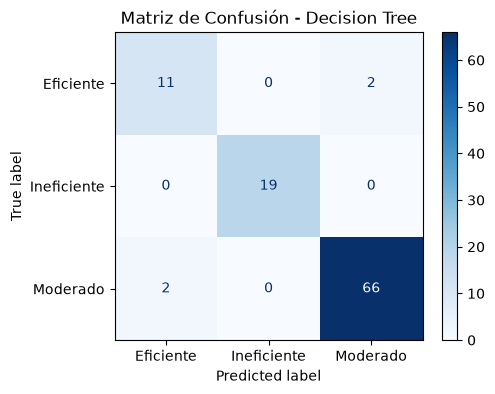

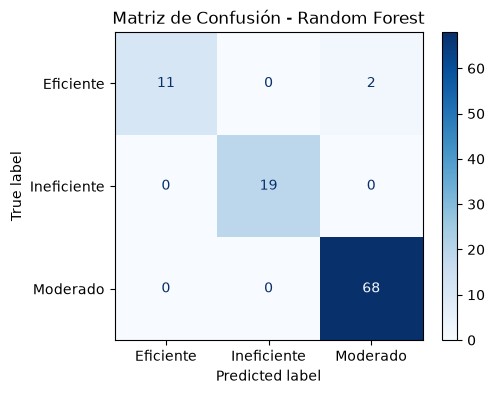

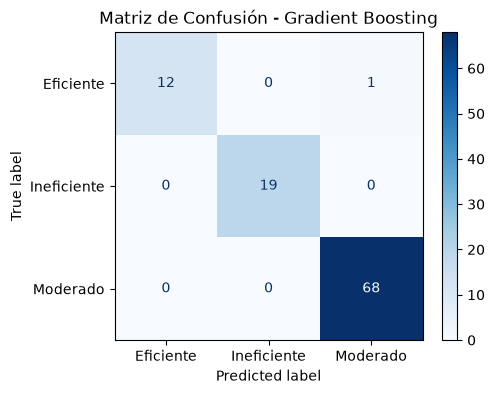

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for nombre, modelo in modelos.items():

    fig, ax = plt.subplots(figsize=(5,4))

    ConfusionMatrixDisplay.from_estimator(
        modelo,
        X_test,
        y_test,
        cmap="Blues",
        ax=ax
    )

    ax.set_title(f"Matriz de Confusión - {nombre}")

    plt.show()

# 4. Interpretabilidad del modelo 

Se analiza la importancia de las variables del modelo seleccionado con el fin de identificar cuáles tienen mayor influencia en la clasificación de la eficiencia energética de los hogares.0

In [104]:
# Modelo seleccionado
modelo_final = modelos["Gradient Boosting"]

In [105]:
import pandas as pd

importancias = pd.DataFrame({

    "Variable": X_train.columns,

    "Importancia": modelo_final.feature_importances_

})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias

,Variable,Importancia
0,consumo_kwh,0.547496
1,cantidad_personas,0.447622
3,temperatura_exterior,0.004883
2,cantidad_equipos,0.000000
4,uso_horario_pico,0.000000


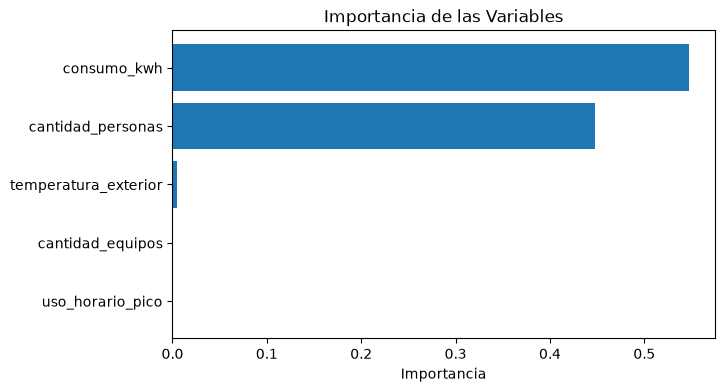

In [117]:
plt.figure(figsize=(7,4))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.xlabel("Importancia")
plt.title("Importancia de las Variables")

plt.gca().invert_yaxis()

# Guardar la figura
plt.savefig(
    "../../reports/importancia_variables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 5. Exportación de Resultados

Se exportan el modelo seleccionado y los archivos generados durante el proceso de entrenamiento para su integración con la API y el backend del proyecto.

In [113]:
modelo_final = modelos["Gradient Boosting"]

import joblib

# Exportar modelo final
joblib.dump(
    modelo_final,
    "../../models/modelo_iee_gradient_boosting.pkl"
)

print("Modelo exportado correctamente.")

Modelo exportado correctamente.


In [114]:
model_data.to_csv(
    "../../data/processed/model_data.csv",
    index=False
)

In [115]:
model_test.to_csv(
    "../../data/processed/model_test.csv",
    index=False
)

In [109]:
metricas.to_csv(
    "../../reports/metricas_modelos.csv",
    index=False
)

print("Métricas exportadas correctamente.")

Métricas exportadas correctamente.


In [110]:
importancias.to_csv(
    "../../reports/importancia_variables.csv",
    index=False
)

print("Importancia de variables exportada correctamente.")

Importancia de variables exportada correctamente.


In [111]:
print("Proceso finalizado correctamente.")

Proceso finalizado correctamente.


In [112]:
print("CD3 completado.")

CD3 completado.
